In [4]:
# ============================================================
# Aircraft Metadata Dataset
# Exploratory Data Analysis (EDA)
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [5]:
# ============================================================
# Load Cleaned Dataset
# ============================================================

aircraft = pd.read_csv(
    "../../data/processed/aircraft/aircraft_metadata_processed.csv",
    parse_dates=[
        "LAST ACTION DATE",
        "CERT ISSUE DATE",
        "AIR WORTH DATE",
        "EXPIRATION DATE"
    ]
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [6]:
print("="*60)
print("Aircraft Metadata Dataset Overview")
print("="*60)

print(f"Rows    : {aircraft.shape[0]:,}")
print(f"Columns : {aircraft.shape[1]}")

Aircraft Metadata Dataset Overview
Rows    : 314,417
Columns : 17


In [7]:
aircraft.head()

,N-NUMBER,SERIAL NUMBER,MFR MDL CODE,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,LAST ACTION DATE,CERT ISSUE DATE,CERTIFICATION,TYPE AIRCRAFT,TYPE ENGINE,STATUS CODE,MODE S CODE,AIR WORTH DATE,EXPIRATION DATE,UNIQUE ID,MODE S CODE HEX
0,100,5334,7100510,17003.0,1940.0,1.0,2023-01-22,2005-05-06,1,4,1,V,50002263,1954-04-30,2027-04-30,600060,A004B3
1,10000,10000,2130004,NaN,NaN,7.0,2024-08-23,2024-08-23,NaN,4,1,V,50003445,NaT,2031-08-31,1443200,A00725
2,10001,A28,9601202,67007.0,1928.0,1.0,2023-07-18,2019-02-27,1,4,1,V,50003446,NaT,2029-02-28,432072,A00726
3,10004,T18208245,2072738,NaN,NaN,7.0,2023-07-22,2013-03-12,NaN,4,2,V,50003451,NaT,2029-03-31,102879,A00729
4,10006,BG-72,1152020,17026.0,1955.0,1.0,2023-04-21,1998-08-26,1U,4,1,V,50003453,1971-09-09,2028-02-29,480110,A0072B


In [8]:
aircraft.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 314417 entries, 0 to 314416
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   N-NUMBER          314417 non-null  object        
 1   SERIAL NUMBER     314417 non-null  object        
 2   MFR MDL CODE      314417 non-null  object        
 3   ENG MFR MDL       276838 non-null  float64       
 4   YEAR MFR          246006 non-null  float64       
 5   TYPE REGISTRANT   313225 non-null  float64       
 6   LAST ACTION DATE  314417 non-null  datetime64[ns]
 7   CERT ISSUE DATE   306526 non-null  datetime64[ns]
 8   CERTIFICATION     280514 non-null  object        
 9   TYPE AIRCRAFT     314417 non-null  object        
 10  TYPE ENGINE       314417 non-null  int64         
 11  STATUS CODE       314417 non-null  object        
 12  MODE S CODE       314417 non-null  int64         
 13  AIR WORTH DATE    272438 non-null  datetime64[ns]
 14  EXPI

In [9]:
aircraft.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
N-NUMBER,314417,314417,9ZX,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SERIAL NUMBER,314417,246556,001,1764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MFR MDL CODE,314417,44983,7102802,4264,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ENG MFR MDL,276838.0,NaN,NaN,NaN,34460.436118,0.0,17026.0,41508.0,41678.0,99999.0,18986.097364
YEAR MFR,246006.0,NaN,NaN,NaN,1984.467363,1909.0,1966.0,1979.0,2006.0,2026.0,24.154516
TYPE REGISTRANT,313225.0,NaN,NaN,NaN,3.417112,1.0,1.0,3.0,7.0,9.0,2.495795
LAST ACTION DATE,314417,NaN,NaN,NaN,2024-01-13 07:17:19.833088,1971-11-24 00:00:00,2023-05-12 00:00:00,2023-08-25 00:00:00,2024-09-20 00:00:00,2026-06-30 00:00:00,NaN
CERT ISSUE DATE,306526,NaN,NaN,NaN,2017-07-05 14:14:59.207245056,1940-12-26 00:00:00,2014-05-07 00:00:00,2020-12-14 00:00:00,2024-01-27 00:00:00,2026-06-30 00:00:00,NaN
CERTIFICATION,280514,313,1N,97923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TYPE AIRCRAFT,314417,11,4,220963,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
categorical_columns = aircraft.select_dtypes(include="object").columns

numerical_columns = aircraft.select_dtypes(include=["int64","float64"]).columns

datetime_columns = aircraft.select_dtypes(include="datetime").columns

print("Categorical Columns")
print(categorical_columns)

print("\nNumerical Columns")
print(numerical_columns)

print("\nDatetime Columns")
print(datetime_columns)

Categorical Columns
Index(['N-NUMBER', 'SERIAL NUMBER', 'MFR MDL CODE', 'CERTIFICATION',
       'TYPE AIRCRAFT', 'STATUS CODE', 'MODE S CODE HEX'],
      dtype='object')

Numerical Columns
Index(['ENG MFR MDL', 'YEAR MFR', 'TYPE REGISTRANT', 'TYPE ENGINE',
       'MODE S CODE', 'UNIQUE ID'],
      dtype='object')

Datetime Columns
Index(['LAST ACTION DATE', 'CERT ISSUE DATE', 'AIR WORTH DATE',
       'EXPIRATION DATE'],
      dtype='object')


In [11]:
aircraft["TYPE AIRCRAFT"].value_counts()

TYPE AIRCRAFT
4    220963
5     49338
6     27539
2      5252
1      4876
H      3004
8      1909
7      1058
9       410
3        49
O        19
Name: count, dtype: int64

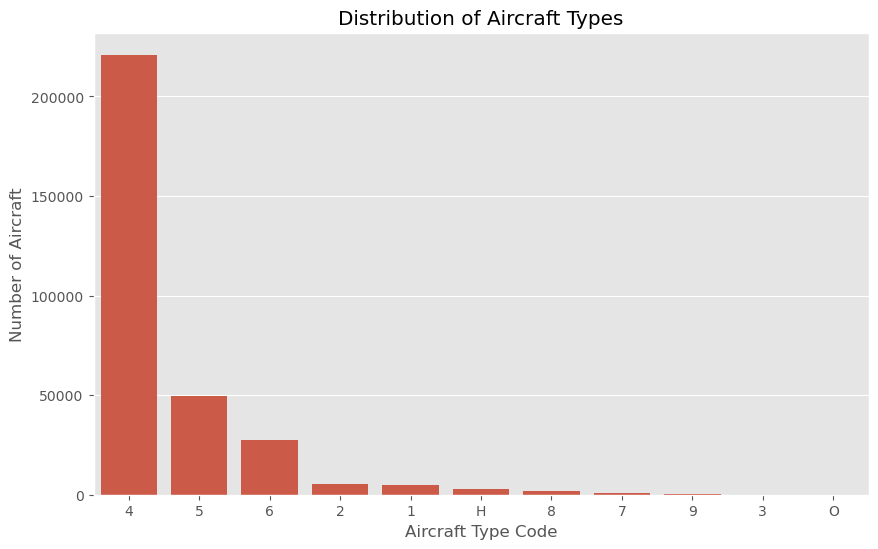

In [12]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=aircraft,
    x="TYPE AIRCRAFT",
    order=aircraft["TYPE AIRCRAFT"].value_counts().index
)

plt.title("Distribution of Aircraft Types")

plt.xlabel("Aircraft Type Code")

plt.ylabel("Number of Aircraft")

plt.show()

In [13]:
aircraft["TYPE ENGINE"].value_counts()

TYPE ENGINE
1     210220
5      27142
8      21308
10     15828
2      14038
3       9732
0       9126
7       5139
4       1801
11        75
9          5
6          3
Name: count, dtype: int64

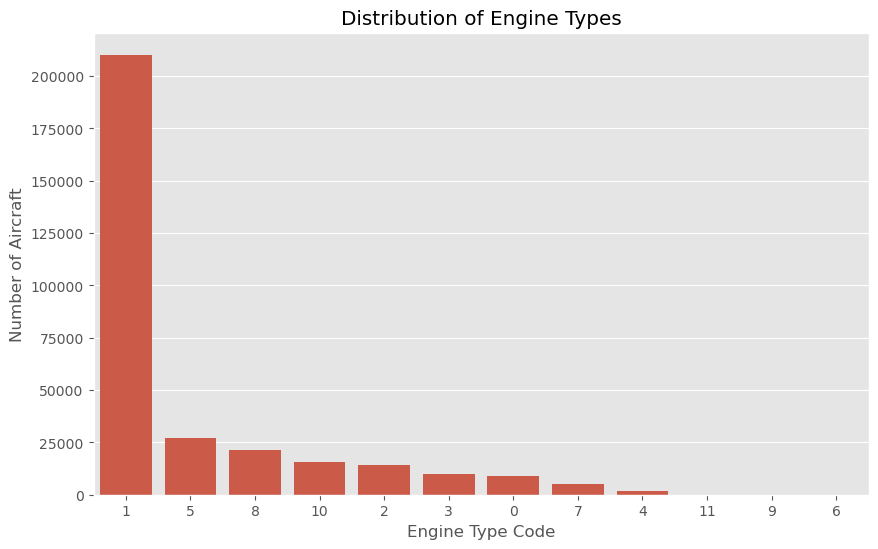

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=aircraft,
    x="TYPE ENGINE",
    order=aircraft["TYPE ENGINE"].value_counts().index
)

plt.title("Distribution of Engine Types")

plt.xlabel("Engine Type Code")

plt.ylabel("Number of Aircraft")

plt.show()

In [15]:
aircraft["STATUS CODE"].value_counts()

STATUS CODE
V     308257
R       1937
M       1221
7        793
2        778
N        273
17       267
3        214
19       137
10       106
9        104
18        95
4         62
22        41
29        28
11        27
20        27
23        18
W         14
12        10
D          8
Name: count, dtype: int64

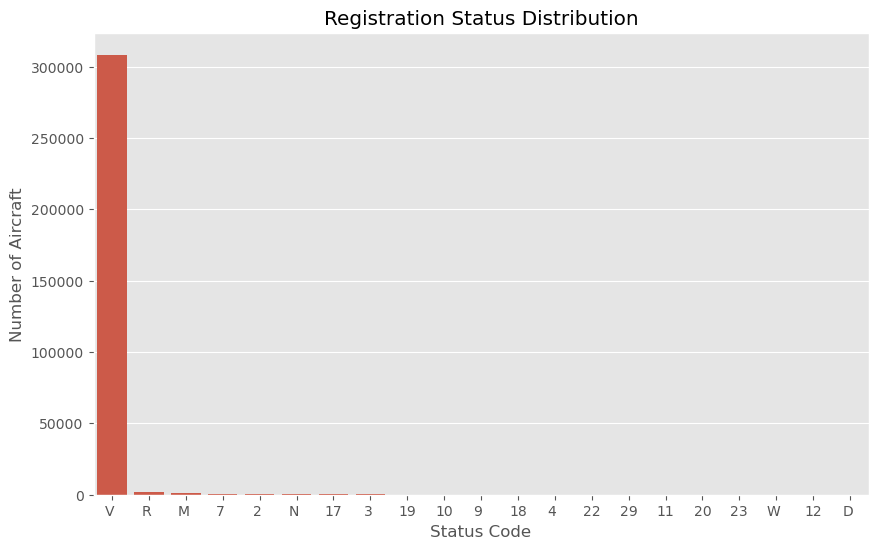

In [16]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=aircraft,
    x="STATUS CODE",
    order=aircraft["STATUS CODE"].value_counts().index
)

plt.title("Registration Status Distribution")

plt.xlabel("Status Code")

plt.ylabel("Number of Aircraft")

plt.show()

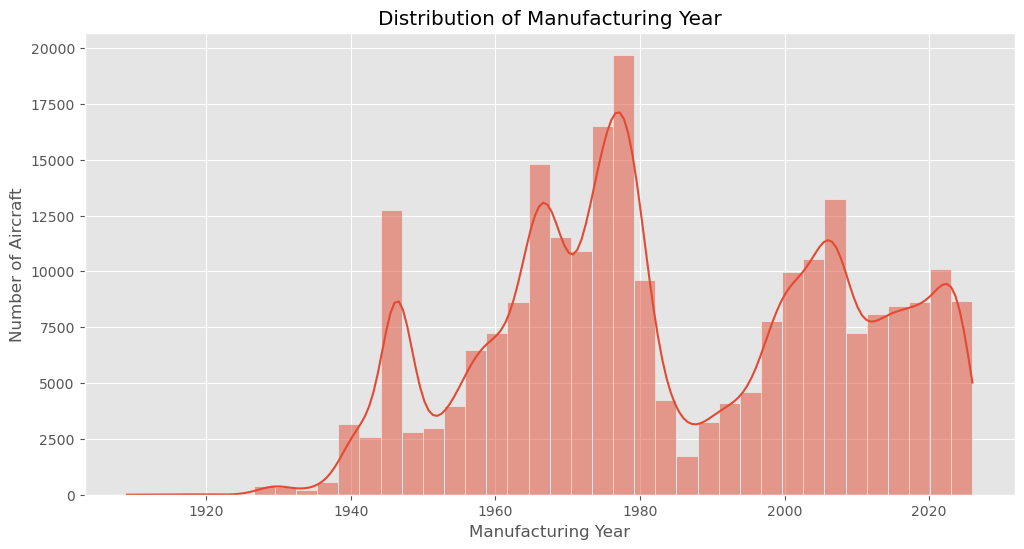

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    aircraft["YEAR MFR"],
    bins=40,
    kde=True
)

plt.title("Distribution of Manufacturing Year")

plt.xlabel("Manufacturing Year")

plt.ylabel("Number of Aircraft")

plt.show()

In [18]:
current_year = pd.Timestamp.now().year

aircraft["Aircraft Age"] = current_year - aircraft["YEAR MFR"]

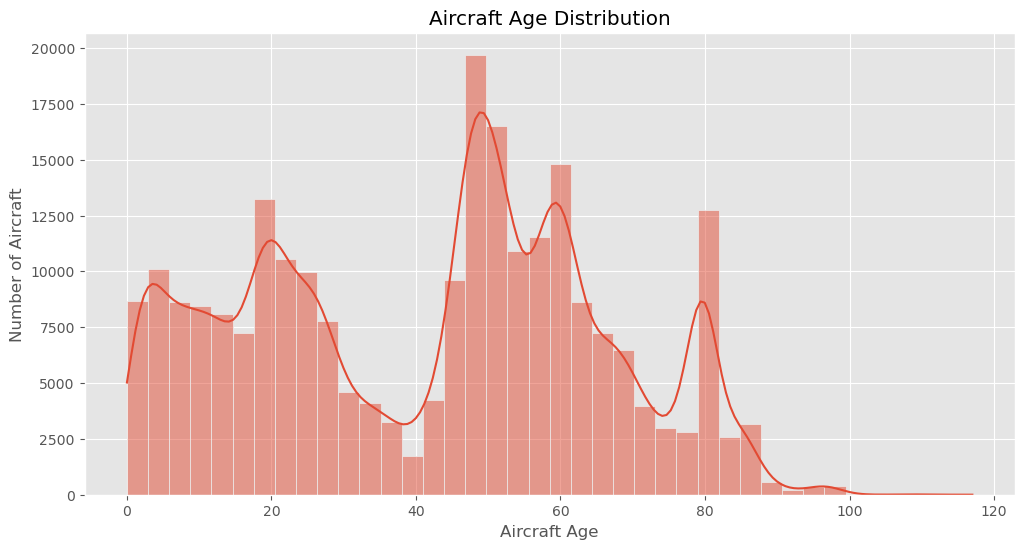

In [19]:
plt.figure(figsize=(12,6))

sns.histplot(
    aircraft["Aircraft Age"],
    bins=40,
    kde=True
)

plt.title("Aircraft Age Distribution")

plt.xlabel("Aircraft Age")

plt.ylabel("Number of Aircraft")

plt.show()

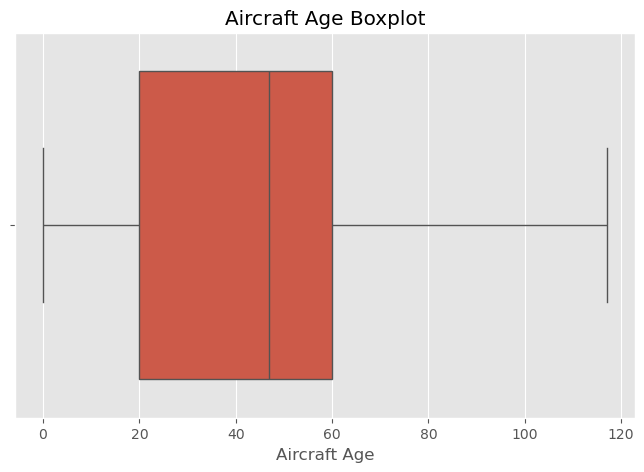

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=aircraft["Aircraft Age"]
)

plt.title("Aircraft Age Boxplot")

plt.show()

In [21]:
aircraft["CERTIFICATION"].value_counts().head(15)

CERTIFICATION
1N            97923
1             42229
1NU           32002
42            29736
1T            21982
1U            16762
1B             4166
43             4065
48A            3646
9A             3479
31             3419
1NA            2783
1C             2434
1A             1379
1G             1351
Name: count, dtype: int64

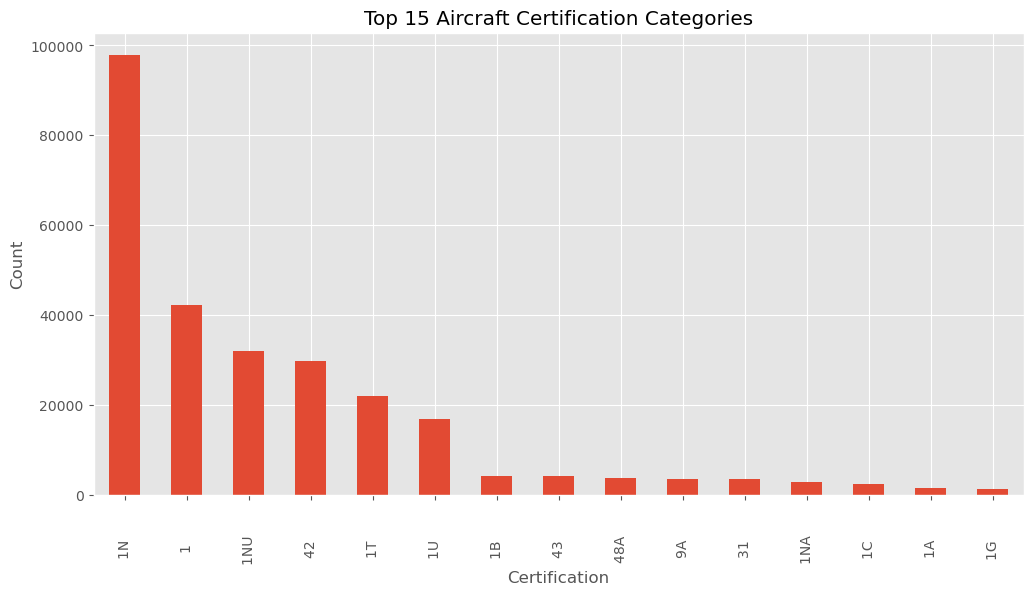

In [22]:
plt.figure(figsize=(12,6))

aircraft["CERTIFICATION"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Aircraft Certification Categories")

plt.xlabel("Certification")

plt.ylabel("Count")

plt.show()

In [23]:
aircraft["TYPE REGISTRANT"].value_counts()

TYPE REGISTRANT
1.0    129790
7.0     86378
3.0     60224
4.0     25935
5.0      5702
2.0      3103
8.0      2076
9.0        17
Name: count, dtype: int64

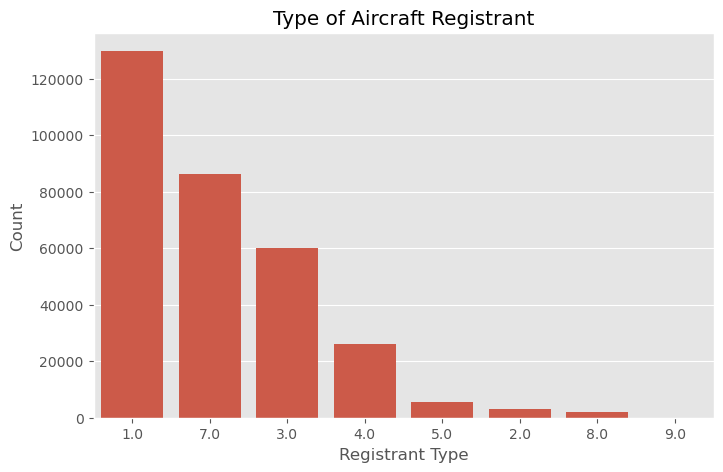

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=aircraft,
    x="TYPE REGISTRANT",
    order=aircraft["TYPE REGISTRANT"].value_counts().index
)

plt.title("Type of Aircraft Registrant")

plt.xlabel("Registrant Type")

plt.ylabel("Count")

plt.show()

In [25]:
activity = aircraft["LAST ACTION DATE"].dt.year.value_counts().sort_index()

activity

LAST ACTION DATE
1971         1
1972         1
1973         1
1977       181
1978        18
1979        10
1980        27
1981         8
1982        18
1983         4
1984         6
1985         6
1986         2
1987         2
1988         1
1989         2
1990         5
1991         4
1992         1
1993         4
1995         3
1996         6
1997         5
1998         6
1999         6
2000         7
2001         8
2002         2
2003         6
2004        27
2005         7
2006        18
2007        12
2008        14
2009        12
2010         7
2011        14
2012        20
2013        27
2014        21
2015        43
2016        51
2017        45
2018        66
2019        88
2020        70
2021       121
2022       136
2023    208572
2024     35254
2025     42159
2026     27282
Name: count, dtype: int64

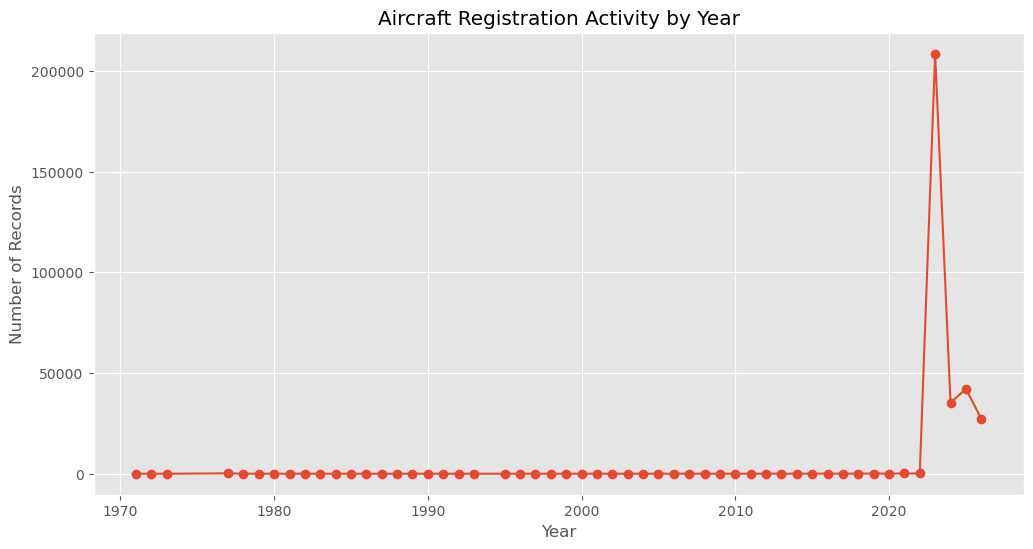

In [26]:
plt.figure(figsize=(12,6))

activity.plot(marker="o")

plt.title("Aircraft Registration Activity by Year")

plt.xlabel("Year")

plt.ylabel("Number of Records")

plt.grid(True)

plt.show()

In [27]:
numerical = aircraft.select_dtypes(include=["int64","float64"])

numerical.corr()

,ENG MFR MDL,YEAR MFR,TYPE REGISTRANT,TYPE ENGINE,MODE S CODE,UNIQUE ID,Aircraft Age
ENG MFR MDL,1.000000,0.288789,0.069798,0.248096,-0.000173,0.118245,-0.288789
YEAR MFR,0.288789,1.000000,0.253187,0.357910,-0.013112,0.510382,-1.000000
TYPE REGISTRANT,0.069798,0.253187,1.000000,0.128508,-0.001315,0.163635,-0.253187
TYPE ENGINE,0.248096,0.357910,0.128508,1.000000,0.001037,0.407580,-0.357910
MODE S CODE,-0.000173,-0.013112,-0.001315,0.001037,1.000000,0.003404,0.013112
UNIQUE ID,0.118245,0.510382,0.163635,0.407580,0.003404,1.000000,-0.510382
Aircraft Age,-0.288789,-1.000000,-0.253187,-0.357910,0.013112,-0.510382,1.000000


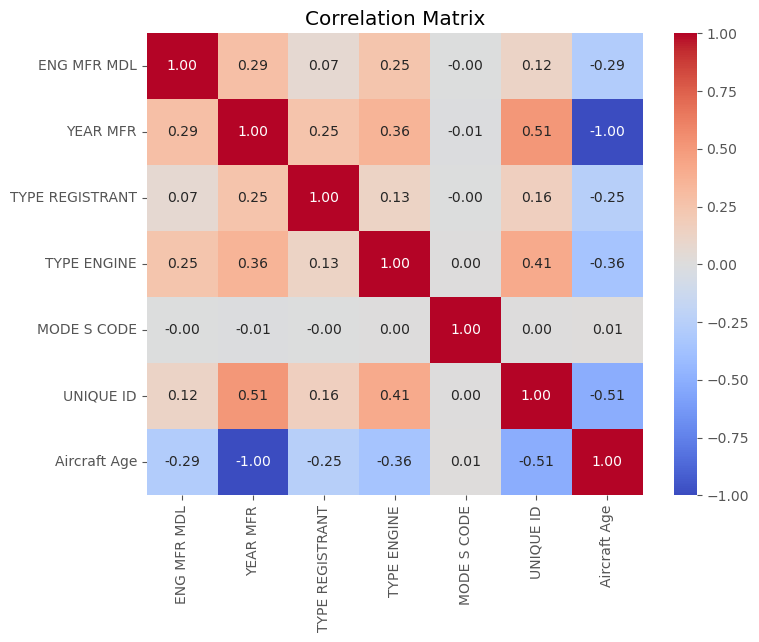

In [28]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numerical.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

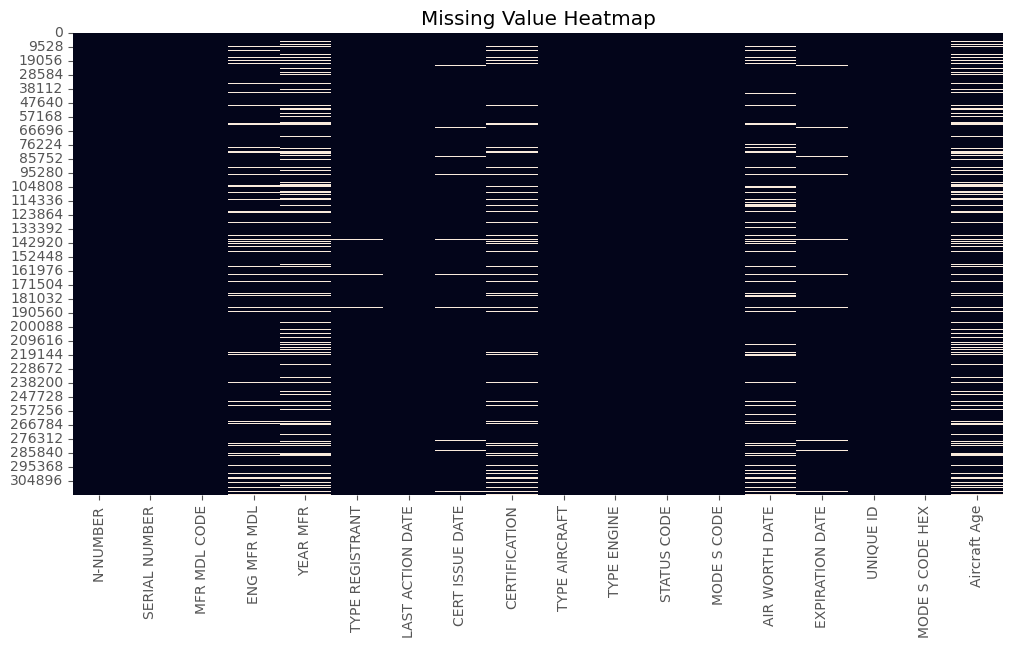

In [29]:
plt.figure(figsize=(12,6))

sns.heatmap(
    aircraft.isnull(),
    cbar=False
)

plt.title("Missing Value Heatmap")

plt.show()